<a href="https://colab.research.google.com/github/navyashreenavy/PADV/blob/main/PADV4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    silhouette_score
)

In [2]:
np.random.seed(42)

In [4]:

# ==========================================
print("--- 1. Loading & Preparing Data ---")
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Standardize features for distance-based clustering algorithms
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset Shape: {X.shape}")
print("Sample Features:\n", X.head(3))

--- 1. Loading & Preparing Data ---
Dataset Shape: (150, 4)
Sample Features:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2


In [5]:
print("\n--- 2. Classification (Random Forest) ---")

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)


--- 2. Classification (Random Forest) ---


In [6]:
# Train Classifier
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [7]:
# Predictions & Evaluation
y_pred = classifier.predict(X_test)
acc = accuracy_score(y_test, y_pred)

In [8]:
print(f"Classification Accuracy: {acc * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Classification Accuracy: 88.89%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45



In [9]:
feature_importances = pd.Series(classifier.feature_importances_, index=iris.feature_names)
print("Top Predictive Features:\n", feature_importances.sort_values(ascending=False))

Top Predictive Features:
 petal width (cm)     0.454892
petal length (cm)    0.400227
sepal length (cm)    0.120608
sepal width (cm)     0.024273
dtype: float64


In [10]:
print("\n--- 3. Clustering (K-Means) ---")

# Apply K-Means with K=3 (number of distinct species)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Calculate Silhouette Score (measures how well-separated clusters are)
sil_score = silhouette_score(X_scaled, cluster_labels)
print(f"K-Means Silhouette Score (K=3): {sil_score:.4f}")


--- 3. Clustering (K-Means) ---
K-Means Silhouette Score (K=3): 0.4599


In [11]:
print("\n--- 3. Clustering (K-Means) ---")

# Apply K-Means with K=3 (number of distinct species)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Calculate Silhouette Score (measures how well-separated clusters are)
sil_score = silhouette_score(X_scaled, cluster_labels)
print(f"K-Means Silhouette Score (K=3): {sil_score:.4f}")


--- 3. Clustering (K-Means) ---
K-Means Silhouette Score (K=3): 0.4599


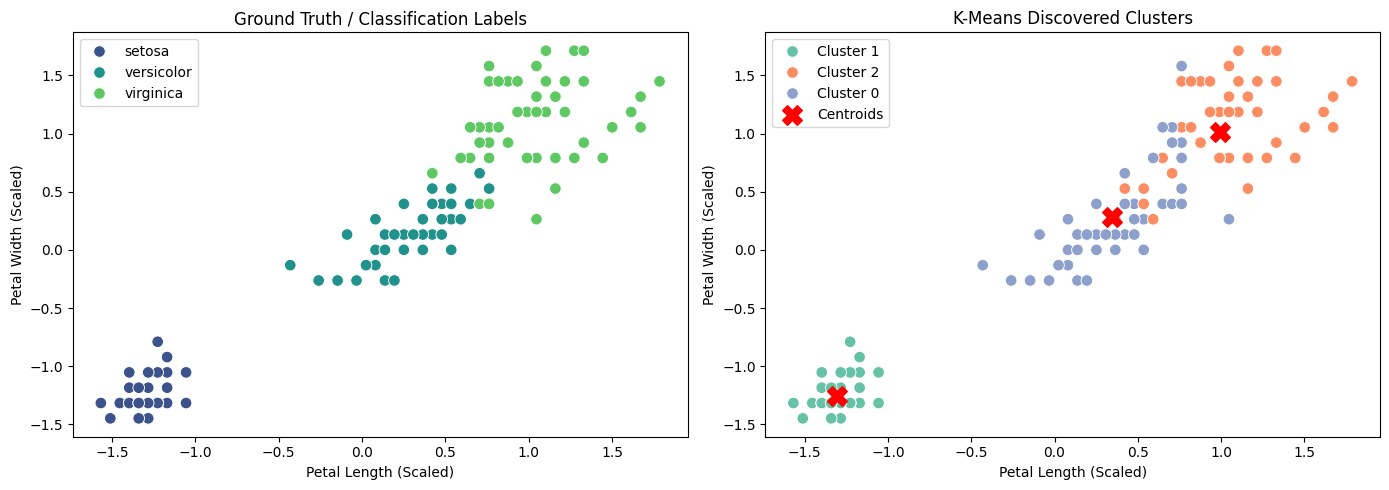

In [13]:
# Create the figure and subplots first
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Ground Truth / Classification Results
sns.scatterplot(
    x=X_scaled[:, 2], y=X_scaled[:, 3], hue=iris.target_names[y],
    palette='viridis', ax=axes[0], s=70
)
axes[0].set_title("Ground Truth / Classification Labels")
axes[0].set_xlabel("Petal Length (Scaled)")
axes[0].set_ylabel("Petal Width (Scaled)")

# Plot 2: K-Means Discovered Clusters
sns.scatterplot(
    x=X_scaled[:, 2], y=X_scaled[:, 3], hue=[f"Cluster {c}" for c in cluster_labels],
    palette='Set2', ax=axes[1], s=70
)

# Plot cluster centroids
centroids = kmeans.cluster_centers_
axes[1].scatter(
    centroids[:, 2], centroids[:, 3], c='red', marker='X', s=200, label='Centroids'
)
axes[1].set_title("K-Means Discovered Clusters")
axes[1].set_xlabel("Petal Length (Scaled)")
axes[1].set_ylabel("Petal Width (Scaled)")
axes[1].legend()

plt.tight_layout()
plt.show()